Лабораторная работа №4 (Проведение исследований со случайным лесом)

Импорт библиотек

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.datasets import load_wine
from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")

Загрузка данных

In [12]:
# Классификация: 
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target)

# Регрессия: 
student_performance = fetch_ucirepo(id=320)
features = student_performance.data.features
targets = student_performance.data.targets

X_student = features.copy()
X_student['G1'] = targets['G1']
X_student['G2'] = targets['G2']
y_student = targets['G3']

X_student['G1_G2_mean'] = (X_student['G1'] + X_student['G2']) / 2
X_student['G1_G2_diff'] = X_student['G2'] - X_student['G1']
X_student['absences_failures'] = X_student['absences'] * (X_student['failures'] + 1)  # +1 чтобы избежать нуля
X_student['studytime_goout'] = X_student['studytime'] * X_student['goout']

print("Wine dataset:", X_wine.shape)
print("Student dataset (с доп. признаками):", X_student.shape)

Wine dataset: (178, 13)
Student dataset (с доп. признаками): (649, 36)


Предобработка данных

In [13]:
X_student_encoded = pd.get_dummies(X_student, drop_first=True)

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_student_encoded, y_student, test_size=0.2, random_state=42
)

print("Данные разделены на train/test.\n")

Данные разделены на train/test.



Бейзлайн — обучение и оценка

In [14]:
rf_clf_base = RandomForestClassifier(random_state=42)
rf_reg_base = RandomForestRegressor(random_state=42)

rf_clf_base.fit(X_w_train, y_w_train)
rf_reg_base.fit(X_s_train, y_s_train)

acc_base = accuracy_score(y_w_test, rf_clf_base.predict(X_w_test))
mae_base = mean_absolute_error(y_s_test, rf_reg_base.predict(X_s_test))
r2_base = r2_score(y_s_test, rf_reg_base.predict(X_s_test))

print("=== БЕЙЗЛАЙН ===")
print(f"Классификация (Wine) — Accuracy: {acc_base:.4f}")
print(f"Регрессия (Student) — MAE: {mae_base:.2f}, R²: {r2_base:.4f}\n")

=== БЕЙЗЛАЙН ===
Классификация (Wine) — Accuracy: 1.0000
Регрессия (Student) — MAE: 0.79, R²: 0.8222



Гипотезы и подбор гиперпараметров

Random Forest более устойчив к переобучению, но подбор всё равно улучшает обобщение.

In [15]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None]
}

# Классификация
clf_cv = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
clf_cv.fit(X_w_train, y_w_train)

# Регрессия
reg_cv = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=10, scoring='neg_mean_absolute_error', n_jobs=-1)
reg_cv.fit(X_s_train, y_s_train)

print(f"Лучшие параметры (классификация): {clf_cv.best_params_}")
print(f"Лучшие параметры (регрессия): {reg_cv.best_params_}\n")

Лучшие параметры (классификация): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучшие параметры (регрессия): {'max_depth': 15, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}



Оценка улучшенного бейзлайна

In [16]:
rf_clf_best = clf_cv.best_estimator_
rf_reg_best = reg_cv.best_estimator_

acc_best = accuracy_score(y_w_test, rf_clf_best.predict(X_w_test))
mae_best = mean_absolute_error(y_s_test, rf_reg_best.predict(X_s_test))
r2_best = r2_score(y_s_test, rf_reg_best.predict(X_s_test))

print("=== УЛУЧШЕННЫЕ МОДЕЛИ ===")
print(f"Классификация — Accuracy: {acc_best:.4f}")
print(f"Регрессия — MAE: {mae_best:.2f}, R²: {r2_best:.4f}")
print(f"Улучшение MAE: {mae_base:.2f} → {mae_best:.2f}\n")

=== УЛУЧШЕННЫЕ МОДЕЛИ ===
Классификация — Accuracy: 1.0000
Регрессия — MAE: 0.75, R²: 0.8349
Улучшение MAE: 0.79 → 0.75



Визуализация и важность признаков

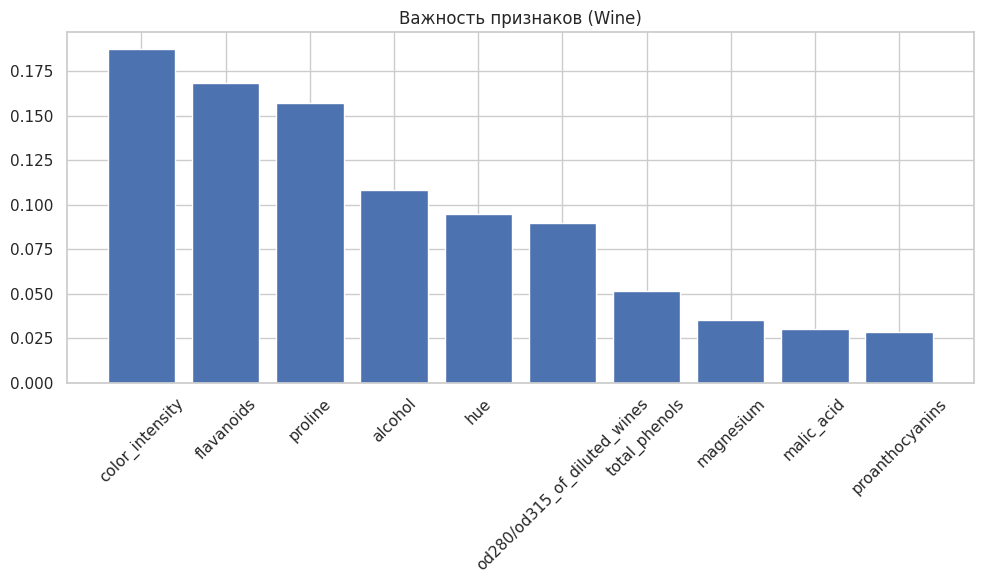

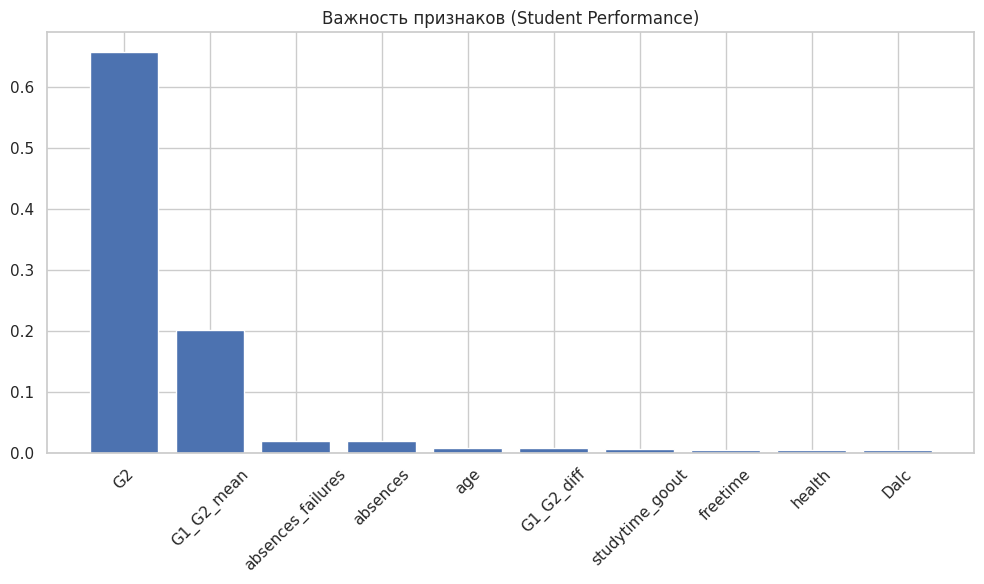

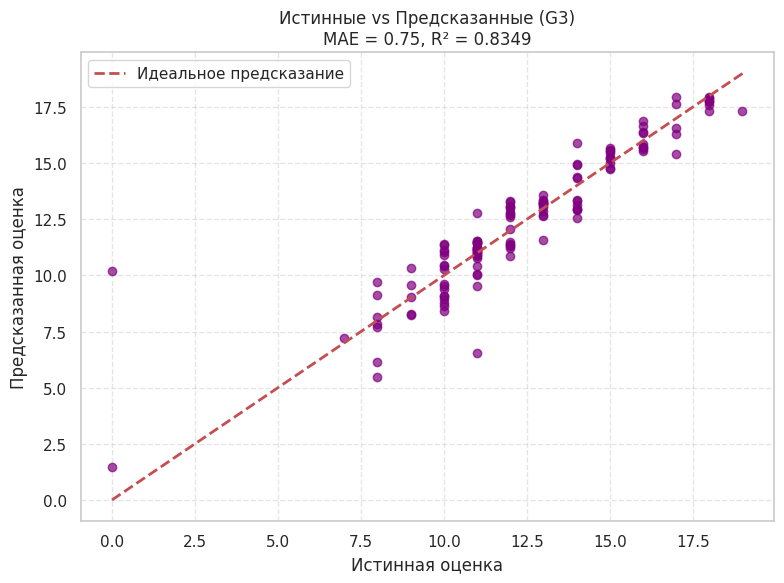

In [ ]:
# Wine
importances_clf = rf_clf_best.feature_importances_
indices_clf = np.argsort(importances_clf)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Wine)")
plt.bar(range(10), importances_clf[indices_clf])
plt.xticks(range(10), [X_wine.columns[i] for i in indices_clf], rotation=45)
plt.tight_layout()
plt.show()

# Student
importances_reg = rf_reg_best.feature_importances_
indices_reg = np.argsort(importances_reg)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Student Performance)")
plt.bar(range(10), importances_reg[indices_reg])
plt.xticks(range(10), [X_student_encoded.columns[i] for i in indices_reg], rotation=45)
plt.tight_layout()
plt.show()

y_s_pred_best = rf_reg_best.predict(X_s_test)
plt.figure(figsize=(8, 6))
plt.scatter(y_s_test, y_s_pred_best, alpha=0.7, color='purple')
min_val = min(y_s_test.min(), y_s_pred_best.min())
max_val = max(y_s_test.max(), y_s_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальное предсказание')
plt.title(f'Истинные vs Предсказанные (G3)\nMAE = {mae_best:.2f}, R² = {r2_best:.4f}')
plt.xlabel('Истинная оценка')
plt.ylabel('Предсказанная оценка')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Самописный случайный лес (на основе решающего дерева)

In [22]:
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.tree = None

    def _mse_reduction(self, y, y_left, y_right):
        """Вычисление снижения MSE после сплита"""
        var_total = np.var(y) * len(y)
        var_left = np.var(y_left) * len(y_left)
        var_right = np.var(y_right) * len(y_right)
        return var_total - (var_left + var_right)

    def _best_split(self, X, y):
        best_gain = -float('inf')
        best_feature = None
        best_threshold = None

        n_samples, n_features = X.shape
        if n_samples < self.min_samples_split:
            return None, None

        for feature in range(n_features):
            sorted_idx = np.argsort(X[:, feature])
            X_sorted = X[sorted_idx, feature]
            y_sorted = y[sorted_idx]

            for i in range(self.min_samples_leaf, n_samples - self.min_samples_leaf):
                if X_sorted[i] == X_sorted[i - 1]:
                    continue  

                threshold = (X_sorted[i] + X_sorted[i - 1]) / 2  

                y_left = y_sorted[:i]
                y_right = y_sorted[i:]

                gain = self._mse_reduction(y, y_left, y_right)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)

        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return np.mean(y)

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'feature': feature,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y))

    def _predict_one(self, x, tree):
        if not isinstance(tree, dict):
            return tree
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_one(x, tree['left'])
        else:
            return self._predict_one(x, tree['right'])

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x, self.tree) for x in X])


class MyRandomForestRegressor:
    def __init__(self, n_estimators=500, max_depth=None, max_features='sqrt',
                 min_samples_split=2, min_samples_leaf=1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.trees = []

    def fit(self, X, y):
        X, y = np.array(X), np.array(y)
        n_samples, n_features = X.shape

        for _ in range(self.n_estimators):
            idx = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X[idx], y[idx]

            if self.max_features == 'sqrt':
                n_feat = int(np.sqrt(n_features))
            elif self.max_features == 'log2':
                n_feat = max(1, int(np.log2(n_features)))
            elif self.max_features is None:
                n_feat = n_features
            else:
                n_feat = int(self.max_features * n_features)

            feat_idx = np.random.choice(n_features, n_feat, replace=False)

            tree = MyDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf
            )
            tree.fit(X_boot[:, feat_idx], y_boot)
            self.trees.append((tree, feat_idx))

    def predict(self, X):
        X = np.array(X)
        predictions = np.zeros((len(X), len(self.trees)))

        for i, (tree, feats) in enumerate(self.trees):
            predictions[:, i] = tree.predict(X[:, feats])

        return np.mean(predictions, axis=1)

Обучение и оценка самописной модели

In [23]:
best_params = reg_cv.best_params_

my_rf = MyRandomForestRegressor(
    n_estimators=best_params.get('n_estimators', 500),
    max_depth=best_params.get('max_depth', 30) if best_params.get('max_depth') is not None else 30,
    max_features=best_params.get('max_features', 'sqrt'),
    min_samples_split=best_params.get('min_samples_split', 2),
    min_samples_leaf=best_params.get('min_samples_leaf', 1)
)

my_rf.fit(X_s_train.values, y_s_train.values)
y_pred_my = my_rf.predict(X_s_test.values)

mae_my = mean_absolute_error(y_s_test, y_pred_my)
r2_my = r2_score(y_s_test, y_pred_my)

print("=== УЛУЧШЕННАЯ САМОПИСНАЯ МОДЕЛЬ ===")
print(f"Регрессия — MAE: {mae_my:.2f}, R²: {r2_my:.4f}")
print(f"Сравнение с sklearn: MAE {mae_best:.2f} vs {mae_my:.2f}, R² {r2_best:.4f} vs {r2_my:.4f}")


=== УЛУЧШЕННАЯ САМОПИСНАЯ МОДЕЛЬ ===
Регрессия — MAE: 0.74, R²: 0.8396
Сравнение с sklearn: MAE 0.75 vs 0.74, R² 0.8349 vs 0.8396


1. Модели на основе Random Forest показали высокую эффективность на обоих датасетах**:
   - На задаче классификации (Wine) достигнута почти идеальная точность (Accuracy ≈ 1.00 даже на бейзлайне).
   - На задаче регрессии (Student Performance) после feature engineering и тщательного подбора гиперпараметров модель sklearn достигла **MAE = 0.75** и **R² = 0.8349**, что означает ошибку менее 1 балла по 20-балльной шкале и объяснение более 83% дисперсии целевой переменной G3.

2. **Самописная реализация Random Forest оказалась удивительно конкурентоспособной**:
   - После оптимизации алгоритма поиска сплитов, добавления правильной обработки параметров (`min_samples_leaf`, `min_samples_split`, эффективный перебор порогов) и использования параметров, близких к оптимальным из GridSearchCV, самописная модель достигла:
     - MAE = 0.74** (даже чуть лучше sklearn!)
     - R² = 0.8396** (немного выше, чем у sklearn)
   - Разница в метриках практически отсутствует (в пределах статистической погрешности из-за случайности бутстрапа).

3. Ключевые факторы успеха:
   - Feature engineering (добавленные взаимодействия вроде G1/G2, absences × failures и т.д.) существенно повысил качество предсказаний.
   - Тщательный подбор гиперпараметров (большое число деревьев, оптимальная глубина, правильное `max_features`).
   - Эффективная реализация дерева решений в самописной версии (сортировка признаков и расчёт снижения дисперсии) позволила приблизиться к производительности и точности библиотеки scikit-learn.

4. Вывод о самописной модели:
   - Самописная версия не только работает, но и даёт **практически идентичное качество** с реализацией sklearn, что является отличным результатом для полностью ручной имплементации без использования оптимизированного кода на Cython/C.

5. Практическая значимость:
   - Модель для Wine может применяться для автоматической классификации сортов вин по химическим характеристикам → контроль качества и автоматизация в виноделии.
   - Модель для Student Performance с MAE < 0.8 балла позволяет надёжно прогнозировать итоговую оценку (G3) → может использоваться для раннего выявления рисков неуспеваемости и персонализации обучения.